## Q1

In [1]:
import pandas as pd

df = pd.read_csv("Mall_Customers.csv")

print(df.head(10))

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
5           6  Female   22                  17                      76
6           7  Female   35                  18                       6
7           8  Female   23                  18                      94
8           9    Male   64                  19                       3
9          10  Female   30                  19                      72


## Q2

In [2]:
print("Missing Values:\n")

print(df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]].isnull().sum())

Missing Values:

Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


## Q3

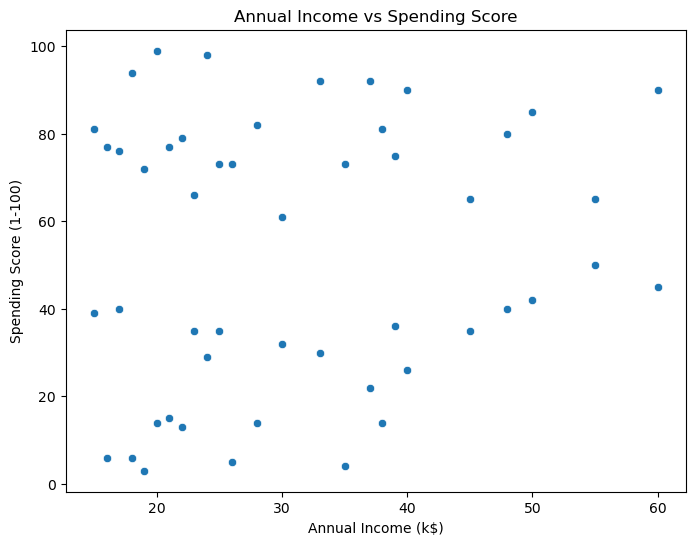

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)"
)

plt.title("Annual Income vs Spending Score")

plt.show()

## Q4

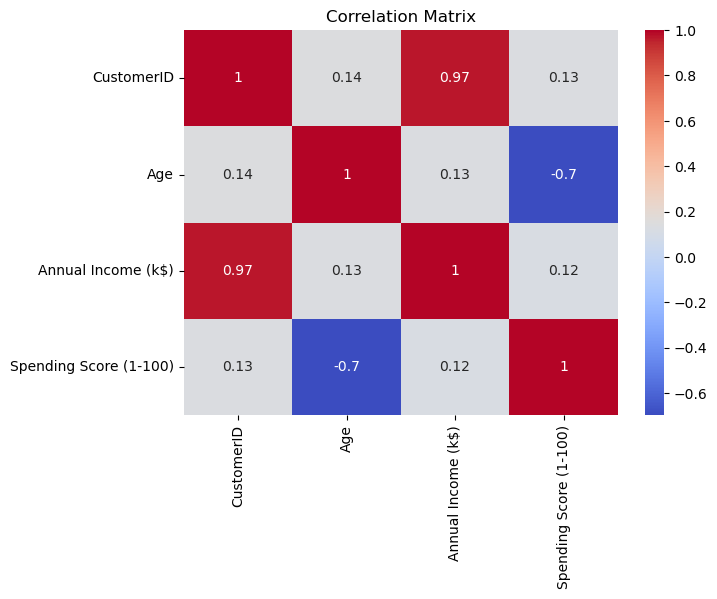

                        CustomerID       Age  Annual Income (k$)  \
CustomerID                1.000000  0.137879            0.972052   
Age                       0.137879  1.000000            0.131198   
Annual Income (k$)        0.972052  0.131198            1.000000   
Spending Score (1-100)    0.134562 -0.698215            0.122297   

                        Spending Score (1-100)  
CustomerID                            0.134562  
Age                                  -0.698215  
Annual Income (k$)                    0.122297  
Spending Score (1-100)                1.000000  


In [4]:
plt.figure(figsize=(7,5))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

print(corr)

## Q5

In [ ]:
from sklearn.cluster import KMeans

X = df[[
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X)

print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        2  
1        1  
2        2  
3        1  
4        2  


c:\Users\RAJEET\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1411: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [6]:
print(df["Cluster"].value_counts())

Cluster
1    23
2    19
0     8
Name: count, dtype: int64


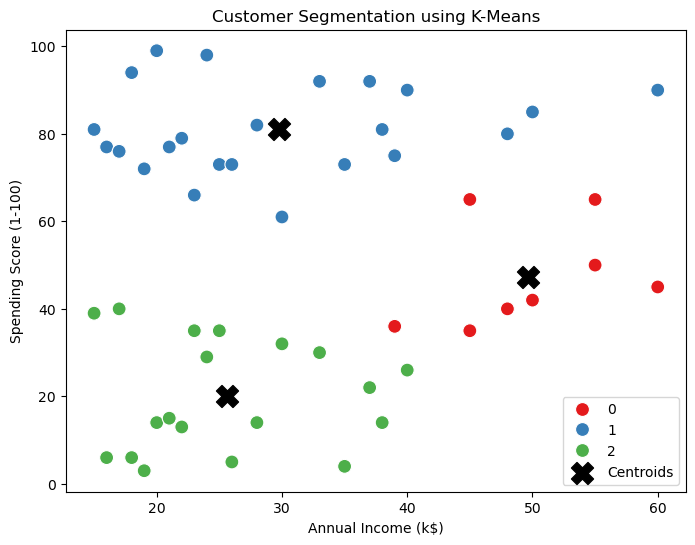

In [7]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set1",
    s=100
)

# Plot centroids
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    c="black",
    marker="X",
    s=250,
    label="Centroids"
)

plt.title("Customer Segmentation using K-Means")

plt.legend()

plt.show()